# Boundary detection within pages: which relational patterns mark structural gaps?

This notebook connects two analysis layers:

1. **Significant whitespace regions** (`empty_regions.compute_page_empty_regions`) --
   geometrically computed gaps within a page that are large enough to plausibly mark a
   content boundary.
2. **Relational line-neighbourhood patterns** (RCC-8 symbols from `relational_patterns`) --
   for each line immediately adjacent to a significant empty region, its full relational
   symbol `(own_cluster, direction, relation, neighbour_cluster)` as used in
   `relational-layout-clustering-table-vs-deeds-demo.ipynb`.

`find_boundary_adjacent_symbols` produces the adjacency pairs; `boundary_symbol_scores`
scores each symbol by its boundary affinity: `boundary_count / corpus_count`. A high
affinity means the symbol occurs at whitespace boundaries much more often than expected
from its overall frequency -- it is a potential *boundary marker pattern*.

**Corpus note:** `compute_page_empty_regions` auto-groups text regions into vertical blocks
before carving, so even NL-HaNA pages with 70-220 regions complete in < 0.01 s. However,
HaNA's inter-cell whitespace is all filtered out by the minimum-size threshold, leaving
no significant empty regions -- boundary-affinity analysis is only informative for
NL-AsnDA (notary deeds), which has genuine structural whitespace.

In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.line_clustering import extract_corpus_line_features, cluster_lines
from archival_structures.analysis.relational_patterns import (
    RelationalPattern, derive_max_vertical_dist,
)
from archival_structures.analysis.empty_regions import (
    compute_page_empty_regions, find_boundary_adjacent_symbols, boundary_symbol_scores,
)

HANA_PAGEXML = Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1')
HANA_THUMBS  = Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1')
ASNA_PAGEXML = Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1')
ASNA_THUMBS  = Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1')
for p in [HANA_PAGEXML, HANA_THUMBS, ASNA_PAGEXML, ASNA_THUMBS]:
    assert p.exists(), p


## Load and split both corpora

20 scans for NL-AsnDA (full analysis), 15 scans for NL-HaNA (loaded to confirm the
lack of significant empty regions -- boundary analysis is run on NL-AsnDA only).

In [2]:
def load_scans(pagexml_dir, n):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]

def split_asna(scans):
    median_width = compute_corpus_median_width(scans)
    pages = []
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            f = get_opening_features(scan, corpus_median_width=median_width)
            v, r = split_scan(scan, f.separation_point)
            pages += [v, r]
        else:
            pages.append(scan)
    return pages

# NL-AsnDA: primary analysis corpus (make_empty_regions is fast: ~0.02s/page)
asna_scans = load_scans(ASNA_PAGEXML, n=100)
asna_scans_by_id = {s.id: s for s in asna_scans}
all_asna_pages = split_asna(asna_scans)
asna_pages = [p for p in all_asna_pages if len(p.get_lines()) > 0]
asna_page_by_id = {p.id: p for p in all_asna_pages}
print(f'NL-AsnDA: {len(asna_scans)} scans -> {len(all_asna_pages)} pages '
      f'({len(asna_pages)} non-empty)')

# NL-HaNA: 15 scans -- compute_page_empty_regions auto-groups regions (< 0.01s/page)
# but produces no significant empty regions after the min-size filter
hana_scans = load_scans(HANA_PAGEXML, n=100)
hana_scans_by_id = {s.id: s for s in hana_scans}
hana_structure = classify_inventory_structure(hana_scans)
all_hana_pages = split_inventory_into_pages(hana_scans, structure=hana_structure)
hana_pages = [p for p in all_hana_pages if len(p.get_lines()) > 0]
hana_page_by_id = {p.id: p for p in all_hana_pages}
print(f'NL-HaNA: {len(hana_scans)} scans -> {len(all_hana_pages)} pages '
      f'({len(hana_pages)} non-empty)')

NL-AsnDA: 100 scans -> 199 pages (155 non-empty)
NL-HaNA: 100 scans -> 174 pages (168 non-empty)


## Cluster text lines and derive neighbourhood threshold (NL-AsnDA)

Same pipeline as `relational-layout-clustering-table-vs-deeds-demo.ipynb`: cluster
lines by normalised left and width, then derive the empirical adjacency distance.

In [3]:
# Line clustering and neighbourhood threshold for NL-AsnDA
asna_line_df = extract_corpus_line_features(asna_pages)
asna_line_df['cluster'] = cluster_lines(
    asna_line_df, features=('left_norm', 'width_norm'), min_cluster_size=5
)
asna_line_clusters = asna_line_df.set_index(['scan_id', 'line_id'])['cluster']
asna_max_vdist = derive_max_vertical_dist(asna_pages, percentile=95.0)
n_lc = asna_line_df['cluster'].nunique() - (1 if -1 in asna_line_df['cluster'].values else 0)
print(f'NL-AsnDA: {len(asna_pages)} pages, {n_lc} line clusters, '
      f'max_vertical_dist={asna_max_vdist}px')


NL-AsnDA: 155 pages, 268 line clusters, max_vertical_dist=86px


## Build the relational pattern corpus (NL-AsnDA)

`RelationalPattern` computes the collection-wide symbol frequency used as the
denominator in `boundary_symbol_scores`.

In [4]:
asna_rp = RelationalPattern(
    asna_pages, asna_line_clusters,
    max_vertical_dist=asna_max_vdist,
    directions=('below', 'right'),
)
print(f'NL-AsnDA: {len(asna_rp.coll_pattern_freq)} distinct relational symbols')


done computing relational patterns, 2368 distinct patterns
done computing tf-idf of relational patterns
NL-AsnDA: 2368 distinct relational symbols


## Compute significant empty regions (NL-AsnDA)

We use a slightly larger threshold (`min_rel_height=0.05`) to focus on structural gaps
that separate content blocks, not just individual-line spacing.

In [5]:
# Significant empty regions for NL-AsnDA (min_rel_height=0.05 for structural gaps)
BOUNDARY_MIN_H = 0.05
BOUNDARY_MIN_W = 0.05

asna_page_er = {}
for page in asna_pages:
    ers = compute_page_empty_regions(page,
                                     min_rel_height=BOUNDARY_MIN_H,
                                     min_rel_width=BOUNDARY_MIN_W)
    if ers:
        asna_page_er[page.id] = ers
n_total = sum(len(v) for v in asna_page_er.values())
print(f'NL-AsnDA: {len(asna_page_er)} pages with significant empty regions '
      f'({n_total} total)')


NL-AsnDA: 154 pages with significant empty regions (599 total)


## Find relational symbols adjacent to empty regions

`find_boundary_adjacent_symbols` finds the text line immediately above and below each
significant empty region and computes all its relational symbols via `LineNeighbourHood`
and RCC-8 -- the same machinery as `RelationalPattern._compute_pattern_freq`.

In [6]:
asna_adj_df = find_boundary_adjacent_symbols(
    asna_pages, asna_line_clusters, asna_page_er,
    max_vertical_dist=asna_max_vdist, directions=('below', 'right'),
)
n_pg = asna_adj_df['page_id'].nunique() if not asna_adj_df.empty else 0
print(f'NL-AsnDA: {len(asna_adj_df)} boundary-adjacent relational symbols '
      f'across {n_pg} pages')
if not asna_adj_df.empty:
    print(asna_adj_df[[
        'own_cluster', 'direction', 'relation', 'neighbour_cluster'
    ]].value_counts().head(5))


NL-AsnDA: 504 boundary-adjacent relational symbols across 150 pages
own_cluster  direction  relation  neighbour_cluster
-1           below      PO        -1                   77
 89          right      DC        -1                   27
-1           right      DC        -1                   11
                                   53                   7
 54          below      PO         54                   7
Name: count, dtype: int64


## Score symbols by boundary affinity

`boundary_symbol_scores` computes `boundary_count / corpus_count` per symbol.
High-affinity symbols are over-represented adjacent to structural whitespace.

In [7]:
asna_scores = boundary_symbol_scores(asna_adj_df, asna_rp.coll_pattern_freq)
print('NL-AsnDA: top 10 boundary-affinity symbols')
print(asna_scores[[
    'own_cluster', 'direction', 'relation', 'neighbour_cluster',
    'boundary_count', 'corpus_count', 'affinity'
]].head(10).to_string(index=False))


NL-AsnDA: top 10 boundary-affinity symbols
 own_cluster direction relation  neighbour_cluster  boundary_count  corpus_count  affinity
         145     below       PO                167               2             1       2.0
         232     below       PO                239               2             1       2.0
          89     right       DC                266               2             1       2.0
          89     right       DC                156               2             1       2.0
          89     right       DC                234               2             1       2.0
         114     below       PO                240               2             1       2.0
          89     right       DC                106               3             2       1.5
         241     below       PO                261               1             1       1.0
         258     below       PO                239               1             1       1.0
         204     below       PO                

## Visualise high-affinity symbol examples

For the top 3 symbols by affinity: page crop showing the adjacent line (red rectangle)
and the empty region (orange border), with the line text printed for legibility.

cluster 145 | below | PO | cluster 167 (affinity=2.00)
  line text: 'valdert van Dalen, timmn wonende'


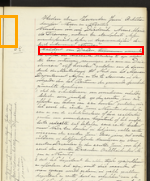


cluster 232 | below | PO | cluster 239 (affinity=2.00)
  line text: 'van voormeld supetaal en de betaling der rente ver'


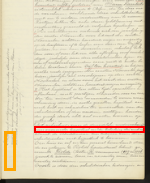


cluster 89 | right | DC | cluster 266 (affinity=2.00)
  line text: '9'


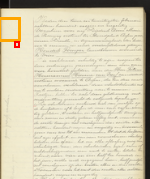

In [8]:
from IPython.display import display

def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id

def find_thumbnail(thumb_dir, scan_id):
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))

def page_thumbnail(page, scans_by_id, thumb_dir):
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(thumb_dir, scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = scans_by_id[scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return (
        image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso')
        else image.crop((sep_x, 0, image.width, image.height))
    )

def show_boundary_example(adj_row, page_by_id, page_er, scans_by_id, thumb_dir):
    page = page_by_id.get(adj_row['page_id'])
    if page is None:
        return None
    er_list = page_er.get(adj_row['page_id'], [])
    er = next((e for e in er_list if e.id == adj_row['empty_region_id']), None)
    if er is None:
        return None
    lines_by_id = {line.id: line for line in page.get_lines()}
    line = lines_by_id.get(adj_row['line_id'])
    if line is None:
        return None
    image = page_thumbnail(page, scans_by_id, thumb_dir).copy()
    sx = image.width / page.coords.width
    sy = image.height / page.coords.height
    draw = ImageDraw.Draw(image)
    ex0 = round(er.coords.left * sx)
    ey0 = round(er.coords.top * sy)
    ex1 = round(er.coords.right * sx)
    ey1 = round(er.coords.bottom * sy)
    for off in range(3):
        draw.rectangle([ex0-off, ey0-off, ex1+off, ey1+off], outline='orange', width=1)
    draw.rectangle(
        [round(line.coords.left*sx), round(line.coords.top*sy),
         round(line.coords.right*sx), round(line.coords.bottom*sy)],
        outline='red', width=2
    )
    y_center = (ey0 + ey1) // 2
    crop_h = max(300, ey1 - ey0 + 100)
    cy0 = max(0, y_center - crop_h // 2)
    cy1 = min(image.height, y_center + crop_h // 2)
    return image.crop((0, cy0, image.width, cy1))

finite = asna_scores[
    asna_scores['affinity'].notna() & (asna_scores['affinity'] != float('inf'))
]
top3 = finite.head(3)
if top3.empty:
    print('No finite-affinity symbols found')
else:
    for _, sym in top3.iterrows():
        adj = asna_adj_df
        matches = adj[
            (adj['own_cluster'] == sym['own_cluster']) &
            (adj['direction'] == sym['direction']) &
            (adj['relation'] == sym['relation']) &
            (adj['neighbour_cluster'] == sym['neighbour_cluster'])
        ]
        if matches.empty:
            continue
        ex = matches.iloc[0]
        label = (f'cluster {sym["own_cluster"]} | {sym["direction"]} | '
                 f'{sym["relation"]} | cluster {sym["neighbour_cluster"]} '
                 f'(affinity={sym["affinity"]:.2f})')
        print(label)
        page = asna_page_by_id.get(ex['page_id'])
        if page:
            ldict = {l.id: l for l in page.get_lines()}
            l = ldict.get(ex['line_id'])
            if l and l.text:
                print(f'  line text: {repr(l.text[:80])}')
        im = show_boundary_example(ex, asna_page_by_id, asna_page_er, asna_scans_by_id, ASNA_THUMBS)
        if im:
            display(im)
        print()


## Summary

The boundary-affinity scores reveal which relational patterns systematically appear
adjacent to structural whitespace in the notary-deeds corpus. High-affinity symbols
are candidates for *within-page boundary markers* -- lines whose type and relationship
to their neighbour signal the end or start of a deed.

Note: for `NL-HaNA` (table register), the minimum-size filter removes almost all
empty regions (inter-cell spacing is too small), so boundary-affinity analysis is not
informative on that corpus -- the table structure has no structural whitespace.

The complementary notebook `boundary-across-pages-demo.ipynb` analyses the same
question at the page-sequence level: which page-layout clusters appear near entirely
blank pages?